# Point Source Injector

<div class="alert alert-block alert-info">

The source injector can produce mock simulated data independent of the MEGAlib software.

Standard data simulation requires the users to install and use MEGAlib to convolve the source model with the detector effects to generate data. The source injector utilizes the response generated by intensive simulation, which contains the statistical detector effects. With the source injector, you can convolve response, source model, and orientation to gain the mock data quickly.

The advantages of using the source injector include:

- No need to install and use MEGAlib
- Get the data much faster than the standard simulation pipeline
- The generated data are in the format that can be used for spectral fitting, localization, imaging, etc.

The disadvantages are:

- The data are binned based on the binning of the response, which means that you lost the unbinned event distribution as you will get from the MEGAlib pipeline.
- If the response is coarse, the data you generated might not be precise.


In [1]:
%%capture
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import astropy.units as u
from astropy.coordinates import SkyCoord

from astromodels.core.polarization import LinearPolarization

from threeML import Band, Model, PointSource

from histpy import Histogram
from mhealpy import HealpixMap

from cosipy import SpacecraftHistory, SourceInjector
from cosipy.polarization.conventions import IAUPolarizationConvention
from cosipy.polarization.polarization_angle import PolarizationAngle
from cosipy.threeml.custom_functions import SpecFromDat
from cosipy.util import fetch_wasabi_file

%matplotlib inline


## Get the data

The data can be downloaded by running the cells below. Each respective cell also gives the wasabi file path and file size.


In [2]:
%%capture
response_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"

In [3]:
%%capture
orientation_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"

## NGC 1068

### Thermal

In [ ]:
source = "NGC1068"
K_inj = 3.1e-1 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.92

spectrum_inj_1068 = Cutoff_powerlaw()

spectrum_inj_1068.K.value = K_inj.value
spectrum_inj_1068.piv.value = piv_inj.value
spectrum_inj_1068.xc.value = xc_inj.value
spectrum_inj_1068.index.value = index_inj

spectrum_inj_1068.K.unit = K_inj.unit
spectrum_inj_1068.piv.unit = piv_inj.unit
spectrum_inj_1068.xc.unit = xc_inj.unit

15:50:06 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=751646;file:///Users/imartin5/software/miniforge3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=49839;file:///Users/imartin5/software/miniforge3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

### Non-thermal

In [ ]:
# K_inj = 0.1*((3.1e-1)*100) / u.cm / u.cm / u.s / u.keV
K_inj = 0.15*spectrum_inj_1068.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -3.8

spectrum_inj_1068_PL = Powerlaw()

spectrum_inj_1068_PL.K.value = K_inj.value
spectrum_inj_1068_PL.piv.value = piv_inj.value
spectrum_inj_1068_PL.index.value = index_inj

spectrum_inj_1068_PL.K.unit = K_inj.unit
spectrum_inj_1068_PL.piv.unit = piv_inj.unit

l = 172.104  # Galactic longitude, degrees
b = -51.934  # Galactic latitude, degrees

In [ ]:
# Define the coordinate of the point source
source_coord = SkyCoord(l=l, b=b, frame="galactic", unit="deg")

# define the NGC1068 point source
point_source = PointSource(
    source, l=source_coord.l.deg, b=source_coord.b.deg, spectral_shape=spectrum_inj_1068
)
# # define the NGC1068 point source
# point_source = PointSource(
#     "NGC1068", l=source_coord.l.deg, b=source_coord.b.deg, spectral_shape=(spectrum_inj_1068 + spectrum_inj_1068_PL)
# )

# define the model. The model can contain multiple point sources.
model = Model(point_source)

### Read orientation file


In [7]:
# Read the 3-month orientation
# It is the pointing of the spacecraft during the the mock simlulation
ori = SpacecraftHistory.open(orientation_path)

### Get the expected counts and save to a data file


In [8]:
# Define an injector by the response
injector = SourceInjector(response_path=response_path)

CPU times: user 2.78 s, sys: 146 ms, total: 2.92 s
Wall time: 2.92 s


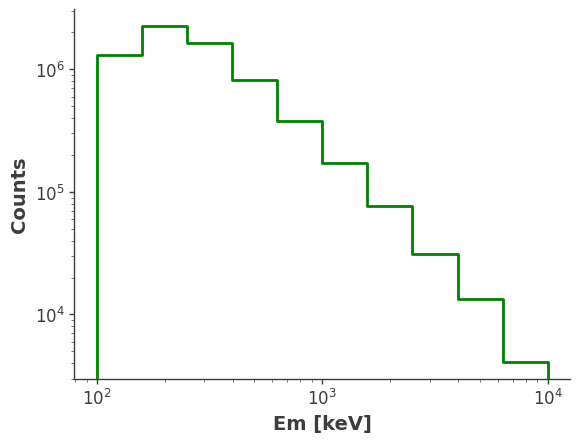

In [ ]:
%%time

file_path = f"/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/Old/{source}_ec_{xc_inj}_DC4_COSI_cpl_{fov}_fovCut.hdf5"

# Check if the file exists and remove it if it does
if os.path.exists(file_path):
    os.remove(file_path)

# Get the data of the injected source
model_injected = injector.inject_model(model = model, orientation = ori, make_spectrum_plot = True, data_save_path = file_path, earth_occ=True
)